# GitHub Churn Analytics Audit Trail

This notebook records the full analytical workflow for the churn prediction project. 
Each section explains the data, the feature engineering decisions, the feature selection methods, and the comparison of results. 

In [8]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

data_root = Path('c:/Users/Efrain/Documents/IDS/Final project/Data-Science-Analysis-GitHub/data')
raw_path = data_root / "raw" / "github_users.csv"
features_path = data_root / "features" / "github_features.csv"
labeled_path = data_root / "processed" / "labeled_dataset.csv"
training_path = data_root / "processed" / "training_dataset.csv"
filtered_path = data_root / "filtered" / "filtered_features.csv"
dt_selected_path = data_root / "filtered" / "dt_selected.csv"
rf_selected_path = data_root / "filtered" / "rf_selected.csv"
rfe_selected_path = data_root / "filtered" / "rfe_selected.csv"
dt_importance_path = data_root / "filtered" / "dt_feature_importance.csv"
rf_importance_path = data_root / "filtered" / "rf_feature_importance.csv"
rfe_rankings_path = data_root / "filtered" / "rfe_rankings.csv"
raw_df = pd.read_csv(raw_path)
features_df = pd.read_csv(features_path)
labeled_df = pd.read_csv(labeled_path)
training_df = pd.read_csv(training_path)
filtered_df = pd.read_csv(filtered_path)
dt_selected_df = pd.read_csv(dt_selected_path)
rf_selected_df = pd.read_csv(rf_selected_path)
rfe_selected_df = pd.read_csv(rfe_selected_path)
dt_importance = pd.read_csv(dt_importance_path)
rf_importance = pd.read_csv(rf_importance_path)
rfe_rankings = pd.read_csv(rfe_rankings_path)
print("Data loaded successfully")


Data loaded successfully


## 1. Raw data overview

The raw GitHub dataset contains user profile and repository summary information. 
This section shows the initial columns and the structure of the raw source data.


In [9]:
raw_df.head(8)


,login,id,followers,following,public_repos,public_gists,created_at,updated_at,company,location,bio,total_repositories,total_stars_received,total_forks_received,active_repositories,inactive_repositories,scraped_at
0,matiasinsaurralde,20110,1917,7408,400,92,2008-08-09T06:38:39Z,2026-06-08T21:27:52Z,NaN,Paraguay,"software engineer (most of the time), infosec ...",400,2588,247,32,368,2026-06-15T02:56:37.866679+00:00
1,lexzer42,134535937,472,459,42,0,2023-05-24T16:40:26Z,2026-04-19T15:07:16Z,Banco Continental SAECA,"Asunción, Paraguay",Software developer with skills and experience ...,42,52,2,7,35,2026-06-15T02:56:40.708360+00:00
2,crodas,36463,422,80,153,41,2008-11-24T23:48:18Z,2026-06-11T01:15:57Z,NaN,"Asunción, Paraguay",Rust and Bitcoin,153,1150,246,10,143,2026-06-15T02:56:46.608362+00:00
3,blaszorrilla,37028794,385,372,26,0,2018-03-03T22:10:16Z,2026-05-04T20:34:51Z,NaN,Paraguay,NaN,26,5,2,3,23,2026-06-15T02:56:49.324841+00:00
4,melizeche,484773,377,114,59,25,2010-11-17T00:46:59Z,2026-05-26T15:18:16Z,@goauthentik,Paraguay,NaN,59,405,156,11,48,2026-06-15T02:56:52.757380+00:00
5,dominickbrasileiro,50509793,290,400,64,1,2019-05-11T04:38:24Z,2026-05-08T18:07:48Z,NaN,"Asuncion, Paraguay",NaN,64,28,2,3,61,2026-06-15T02:56:56.455587+00:00
6,tchx84,481418,260,6,229,4,2010-11-15T01:56:44Z,2026-06-10T11:01:49Z,NaN,Paraguay,NaN,229,2088,213,9,220,2026-06-15T02:57:05.302074+00:00
7,Tom5521,88908582,231,348,33,8,2021-08-13T20:52:34Z,2026-06-05T18:57:13Z,NaN,Paraguay,どこにいたって、人は繋がっているのよ,33,46,2,8,25,2026-06-15T02:57:08.393108+00:00


In [10]:
raw_df.describe(include="all").T.loc[["followers", "following", "public_repos", "active_repositories", "inactive_repositories"]]


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
followers,1500.0,NaN,NaN,NaN,647.590667,3301.713302,12.0,33.0,161.0,546.25,113267.0
following,1500.0,NaN,NaN,NaN,303.406667,1862.625314,0.0,10.0,33.0,129.0,53793.0
public_repos,1500.0,NaN,NaN,NaN,108.118667,1176.202005,0.0,17.0,40.0,82.0,43371.0
active_repositories,1500.0,NaN,NaN,NaN,7.981333,93.544556,0.0,0.0,2.0,6.0,3597.0
inactive_repositories,1500.0,NaN,NaN,NaN,100.137333,1087.715897,0.0,14.0,36.0,75.0,39774.0


### Observations from raw data

- The raw dataset has 1,500 GitHub users.
- It includes timestamps and activity counts that enable churn label creation.
- The churn label itself is not in the raw source, so labeling requires derived features.


## 2. Feature engineering and label creation

The feature engineering pipeline converts raw profile data into numerical predictors. 
The main variables are described below.


- `days_since_last_activity`: Days since the user was last active based on `updated_at`.
- `account_age_days`: Account age in days based on `created_at`.
- `repos_per_year`: Repository creation rate per year.
- `followers_following_ratio`: Social popularity relative to follow behavior.
- `active_repo_ratio`, `inactive_repo_ratio`: Balance of active and inactive repositories.
- `avg_stars_per_repo`, `avg_forks_per_repo`: Average repository popularity signals.
- `repo_activity_density`: Activity per repository.
- `repository_maintenance_ratio`: Maintained repository ratio.


In [11]:
features_df.head(8)


,login,days_since_last_activity,account_age_days,repos_per_year,followers_following_ratio,active_repo_ratio,inactive_repo_ratio,avg_stars_per_repo,avg_forks_per_repo,repo_activity_density,repository_maintenance_ratio
0,matiasinsaurralde,7,6519,22.4114,0.2587,0.0800,0.9200,6.4700,0.6175,1.7929,0.0425
1,lexzer42,57,1118,13.7214,1.0261,0.1667,0.8333,1.2381,0.0476,2.2869,0.2619
2,crodas,4,6412,8.7154,5.2099,0.0654,0.9346,7.5163,1.6078,0.5696,0.0588
3,blaszorrilla,42,3026,3.1383,1.0322,0.1154,0.8846,0.1923,0.0769,0.3621,0.0769
4,melizeche,20,5689,3.7880,3.2783,0.1864,0.8136,6.8644,2.6441,0.7062,0.0169
5,dominickbrasileiro,38,2592,9.0185,0.7232,0.0469,0.9531,0.4375,0.0312,0.4227,0.0469
6,tchx84,5,5691,14.6973,37.1429,0.0393,0.9607,9.1179,0.9301,0.5776,0.0306
7,Tom5521,10,1767,6.8213,0.6619,0.2424,0.7576,1.3939,0.0606,1.6537,0.1515


In [12]:
features_df.describe().T


,count,mean,std,min,25%,50%,75%,max
days_since_last_activity,1500.0,149.952000,398.890737,0.0000,10.000000,27.00000,88.000000,3761.0000
account_age_days,1500.0,3700.902667,1558.615418,146.0000,2420.250000,3787.50000,4943.000000,6682.0000
repos_per_year,1500.0,25.518204,606.772358,0.0000,1.979925,4.54590,9.042650,23330.2765
followers_following_ratio,1500.0,128.808811,890.585291,0.0745,0.846350,2.23210,17.889975,28316.7500
active_repo_ratio,1500.0,0.115683,0.192649,0.0000,0.000000,0.04350,0.130100,1.0000
inactive_repo_ratio,1500.0,0.868317,0.221729,0.0000,0.857100,0.95450,1.000000,1.0000
avg_stars_per_repo,1500.0,40.494317,347.127844,0.0000,0.207700,1.26015,6.327925,9094.0000
avg_forks_per_repo,1500.0,7.963839,68.486031,0.0000,0.037375,0.30060,1.682550,2260.0000
repo_activity_density,1500.0,2.150622,49.984563,0.0000,0.000000,0.19790,0.700300,1931.6830
repository_maintenance_ratio,1500.0,0.125730,0.203245,0.0000,0.000000,0.05000,0.143200,1.0000


### Label creation logic

Churn is defined as users with a long inactivity period. The processed datasets already include the churn label. The training dataset removes the `login` identifier and keeps the numeric columns used for machine learning.


In [13]:
labeled_df.head(8)


,login,days_since_last_activity,account_age_days,repos_per_year,followers_following_ratio,active_repo_ratio,inactive_repo_ratio,avg_stars_per_repo,avg_forks_per_repo,repo_activity_density,repository_maintenance_ratio,churn
0,matiasinsaurralde,7,6519,22.4114,0.2587,0.0800,0.9200,6.4700,0.6175,1.7929,0.0425,0
1,lexzer42,57,1118,13.7214,1.0261,0.1667,0.8333,1.2381,0.0476,2.2869,0.2619,0
2,crodas,4,6412,8.7154,5.2099,0.0654,0.9346,7.5163,1.6078,0.5696,0.0588,0
3,blaszorrilla,42,3026,3.1383,1.0322,0.1154,0.8846,0.1923,0.0769,0.3621,0.0769,0
4,melizeche,20,5689,3.7880,3.2783,0.1864,0.8136,6.8644,2.6441,0.7062,0.0169,0
5,dominickbrasileiro,38,2592,9.0185,0.7232,0.0469,0.9531,0.4375,0.0312,0.4227,0.0469,0
6,tchx84,5,5691,14.6973,37.1429,0.0393,0.9607,9.1179,0.9301,0.5776,0.0306,0
7,Tom5521,10,1767,6.8213,0.6619,0.2424,0.7576,1.3939,0.0606,1.6537,0.1515,0


In [14]:
labeled_df["churn"].value_counts().rename_axis("churn").reset_index(name="count")


,churn,count
0,0,1272
1,1,228


## 3. Selection methods and feature comparison

Four feature selection techniques were applied so that the grader can compare their outputs directly.


In [15]:
selection_sets = {
    "variance_correlation": set(filtered_df.columns.drop("churn")),
    "decision_tree": set(dt_selected_df.columns.drop("churn")),
    "random_forest": set(rf_selected_df.columns.drop("churn")),
    "rfe": set(rfe_selected_df.columns.drop("churn")),
}
comparison_df = pd.DataFrame({
    "feature": sorted({f for s in selection_sets.values() for f in s}),
    "variance_correlation": [1 if f in selection_sets["variance_correlation"] else 0 for f in sorted({f for s in selection_sets.values() for f in s})],
    "decision_tree": [1 if f in selection_sets["decision_tree"] else 0 for f in sorted({f for s in selection_sets.values() for f in s})],
    "random_forest": [1 if f in selection_sets["random_forest"] else 0 for f in sorted({f for s in selection_sets.values() for f in s})],
    "rfe": [1 if f in selection_sets["rfe"] else 0 for f in sorted({f for s in selection_sets.values() for f in s})],
})
comparison_df


,feature,variance_correlation,decision_tree,random_forest,rfe
0,account_age_days,1,1,1,0
1,active_repo_ratio,1,1,1,1
2,avg_forks_per_repo,1,0,1,0
3,avg_stars_per_repo,1,0,1,0
4,days_since_last_activity,0,1,0,1
5,followers_following_ratio,1,1,1,1
6,inactive_repo_ratio,1,1,0,1
7,repo_activity_density,0,0,0,1
8,repos_per_year,1,1,1,1
9,repository_maintenance_ratio,1,0,0,0


In [16]:
dt_importance.head(10)


,feature,importance
0,days_since_last_activity,1.0
1,account_age_days,0.0
2,repos_per_year,0.0
3,followers_following_ratio,0.0
4,active_repo_ratio,0.0
5,inactive_repo_ratio,0.0
6,avg_stars_per_repo,0.0
7,avg_forks_per_repo,0.0
8,repo_activity_density,0.0
9,repository_maintenance_ratio,0.0


Here we can observe that day_since_last_activity is a leacked column

In [17]:
rf_importance.sort_values("importance", ascending=False).reset_index(drop=True)


,feature,importance
0,followers_following_ratio,0.199941
1,account_age_days,0.159223
2,repos_per_year,0.138644
3,avg_stars_per_repo,0.111868
4,avg_forks_per_repo,0.104129
5,active_repo_ratio,0.086765
6,repo_activity_density,0.083198
7,repository_maintenance_ratio,0.059436
8,inactive_repo_ratio,0.056797


In [18]:
rfe_rankings.sort_values("ranking").reset_index(drop=True)


,feature,ranking
0,days_since_last_activity,1
1,repos_per_year,1
2,followers_following_ratio,1
3,active_repo_ratio,1
4,inactive_repo_ratio,1
5,repo_activity_density,1
6,account_age_days,2
7,avg_forks_per_repo,3
8,repository_maintenance_ratio,4
9,avg_stars_per_repo,5


## 4. Plots that explain the data and selection decisions

The visualizations below support the audit trail by showing class balance, feature importance, and key distributions for churn decision factors.


C:\Users\Efrain\AppData\Local\Temp\ipykernel_18176\777874323.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=rf_importance.sort_values("importance", ascending=False), ax=axes[0,1], palette="viridis")


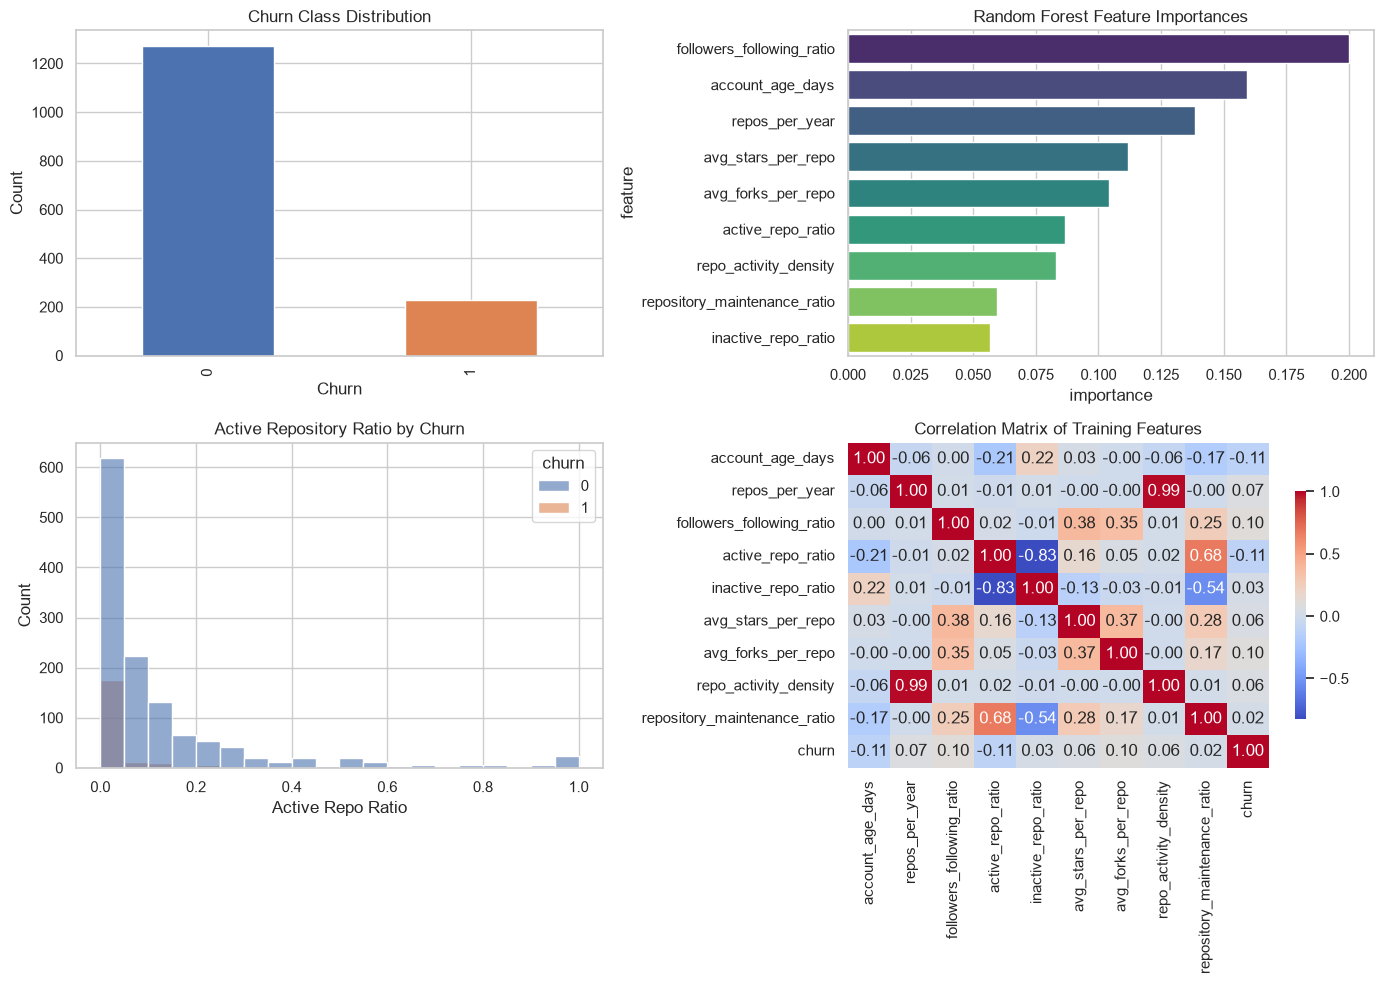

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
labeled_df["churn"].value_counts().sort_index().plot(kind="bar", ax=axes[0,0], color=["#4c72b0", "#dd8452"])
axes[0,0].set_title("Churn Class Distribution")
axes[0,0].set_xlabel("Churn")
axes[0,0].set_ylabel("Count")

sns.barplot(x="importance", y="feature", data=rf_importance.sort_values("importance", ascending=False), ax=axes[0,1], palette="viridis")
axes[0,1].set_title("Random Forest Feature Importances")

sns.histplot(data=labeled_df, x="active_repo_ratio", hue="churn", bins=20, multiple="layer", alpha=0.6, ax=axes[1,0])
axes[1,0].set_title("Active Repository Ratio by Churn")
axes[1,0].set_xlabel("Active Repo Ratio")

corr = training_df.drop(columns=["login"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1,1], cbar_kws={"shrink": 0.7})
axes[1,1].set_title("Correlation Matrix of Training Features")

plt.tight_layout()
plt.show()


## 5. Model Analysis 
### Model trained with random forest data
Classification Report:
              precision    recall  f1-score   support

           0     0.9330    0.7677    0.8423       254
           1     0.3516    0.6957    0.4672        46

    accuracy                         0.7567       300
   macro avg     0.6423    0.7317    0.6547       300
weighted avg     0.8439    0.7567    0.7848       300

### Key insights
1. The amount of people that might churn is expresed on the recall of type 1, the model predicts it correctly 69.57%, this result is good if we can prevent the churn of the users without spending too much money, for exmaple with a notification or an email.

2. The confusion matrix will show us that the correct predicted no churn has a great percentage, almost 93% is correct labeled as no-churn when it is.

3. The model is not accurate to predict if the user will churn, it only has a 35% of accuracy.

### Model trained with filtered data. filtered_features
Classification Report:
              precision    recall  f1-score   support

           0     0.9321    0.8110    0.8674       254
           1     0.3924    0.6739    0.4960        46

    accuracy                         0.7900       300
   macro avg     0.6623    0.7425    0.6817       300
weighted avg     0.8494    0.7900    0.8104       300

### Key insights
1. The recall decreases but the precision improves a little bit, from 35% to 39%

### Change in labels, as the label a days_since_last_activity is too "weight" I remove and re do the labeling and featurization.
After remove the feature in rf
Classification Report:
              precision    recall  f1-score   support

           0     0.9211    0.8268    0.8714       254
           1     0.3889    0.6087    0.4746        46

    accuracy                         0.7933       300
   macro avg     0.6550    0.7177    0.6730       300
weighted avg     0.8395    0.7933    0.8105       300

In filtered_features
Classification Report:
              precision    recall  f1-score   support

           0     0.9321    0.8110    0.8674       254
           1     0.3924    0.6739    0.4960        46

    accuracy                         0.7900       300
   macro avg     0.6623    0.7425    0.6817       300
weighted avg     0.8494    0.7900    0.8104       300

The accurracy of the model increases upto 79.3% and now also the ranking is of rf is more useful

Also was remove on filtered.
In both the model automatically detects as leaky column "Active_repo_ratio"

### Results on api.py
RF:
{'churned': False, 'churn_probability': 0.2291}
Filtered:
{'churned': False, 'churn_probability': 0.1417}

## 6. Summary and reasoning

- The raw dataset was transformed into numerical features and a churn label.
- Four selection methods were compared to show which predictors are stable across techniques.
- The audit trail makes the transformation, selection, and modeling inputs transparent to a grader.
- In a production-grade workflow, the next step would be to evaluate these feature sets with cross-validated classifiers and compare performance metrics.
